# RFM Analysis

* R - Recency : How recently a customer has made a purchase.
* F - Frequency : How often a customer makes a purchase.
* M - Monetory : How much money a customer spends in total.

In [162]:
# Liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Ignore harmless warnings

import warnings
warnings.filterwarnings('ignore')

In [163]:
data = pd.read_csv('E-com_Data.csv')


In [164]:
# Data sample
data.head()

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN


In [165]:
# Data Dimension
data.shape

(541116, 12)

In [166]:
# Columns needed for RFM Analysis
    # Recency : Date of purchase
    # Frequency : Invoice No
    # Monetory : Price

In [167]:
# Retaning the columns needed for analysis

data = data[['CustomerID','InvoieNo','Date of purchase','Price']]

# New data sample
data.head()


,CustomerID,InvoieNo,Date of purchase,Price
0,4355.0,398177.0,29-10-2017,1926.0
1,4352.0,394422.0,05-10-2017,1740.0
2,4352.0,394422.0,12-10-2017,1866.0
3,4352.0,388633.0,22-08-2017,1869.0
4,4352.0,394422.0,10-10-2017,1888.0


In [168]:
# Renaming the columns
data.rename(columns={'InvoieNo':'InvoiceNo',
                    'Date of purchase':'Date'},inplace=True)
data.head()

,CustomerID,InvoiceNo,Date,Price
0,4355.0,398177.0,29-10-2017,1926.0
1,4352.0,394422.0,05-10-2017,1740.0
2,4352.0,394422.0,12-10-2017,1866.0
3,4352.0,388633.0,22-08-2017,1869.0
4,4352.0,394422.0,10-10-2017,1888.0


In [169]:
# Missing value propotion

round(data.isnull().mean()*100,2)

CustomerID    25.30
InvoiceNo      0.58
Date           0.58
Price          0.58
dtype: float64

In [170]:
#Dropping the missing value
data = data.dropna(subset=['CustomerID'])

round(data.isnull().mean()*100,2)

CustomerID    0.0
InvoiceNo     0.0
Date          0.0
Price         0.0
dtype: float64

In [171]:
# data duplicates

data.duplicated().sum()

1330

In [172]:
# Dropping duplicated

data = data.drop_duplicates(ignore_index=True)


In [173]:
data.duplicated().sum()

0

In [174]:
# data type check
data.dtypes

CustomerID    float64
InvoiceNo     float64
Date           object
Price         float64
dtype: object

In [175]:
# data typecasting

data['CustomerID'] = data['CustomerID'].astype('int')
data['InvoiceNo'] = data['InvoiceNo'].astype('int')
data['Date'] = pd.to_datetime(data['Date'])

In [176]:
data.dtypes

CustomerID             int32
InvoiceNo              int32
Date          datetime64[ns]
Price                float64
dtype: object

In [177]:
data.head()

,CustomerID,InvoiceNo,Date,Price
0,4355,398177,2017-10-29,1926.0
1,4352,394422,2017-10-05,1740.0
2,4352,394422,2017-10-12,1866.0
3,4352,388633,2017-08-22,1869.0
4,4352,394422,2017-10-10,1888.0


In [178]:
# Maximun date from date column
print(data['Date'].max())

#Minimum date from date column
print(data['Date'].min())


# Finding the unique max date values for customer id
data[data['Date'] == data['Date'].max()]['CustomerID'].nunique()

2017-12-19 00:00:00
2016-12-02 00:00:00


25

In [179]:
# latest date of purchase
latest_date = dt.datetime(2017,12,20)
latest_date

datetime.datetime(2017, 12, 20, 0, 0)

# RFM Analysis

In [180]:
# Derive RFM
RFMScore = data.groupby('CustomerID').agg({'Date': lambda x:(latest_date-x.max()).days,  # Recency
                                          'InvoiceNo': lambda x: x.count(),              # Frequency
                                          'Price': lambda x: x.sum()})                   # Monetory

# Renaming the columns

RFMScore.rename(columns={'Date': 'Recency',
                        'InvoiceNo':'Frequency',
                        'Price':'Monetory'},inplace=True)

In [181]:
RFMScore

,Recency,Frequency,Monetory
CustomerID,,,
2,4,181,550416.0
3,77,27,257404.0
4,19,72,176613.0
5,311,16,41976.0
6,37,84,151822.0
...,...,...,...
4368,278,10,20480.0
4369,181,7,10774.0
4370,9,13,24962.0


In [182]:
# Converting the data into dataframe
RFMScore.reset_index()

,CustomerID,Recency,Frequency,Monetory
0,2,4,181,550416.0
1,3,77,27,257404.0
2,4,19,72,176613.0
3,5,311,16,41976.0
4,6,37,84,151822.0
...,...,...,...,...
4344,4368,278,10,20480.0
4345,4369,181,7,10774.0
4346,4370,9,13,24962.0
4347,4371,4,751,279720.0


In [183]:
# min max values for each attributes

for cols in RFMScore.columns:
    print(f' For {cols} the minimum value is {RFMScore[cols].min()} and the maximum value is {RFMScore[cols].max()}' )

 For Recency the minimum value is 1 and the maximum value is 381
 For Frequency the minimum value is 1 and the maximum value is 7919
 For Monetory the minimum value is -50372.0 and the maximum value is 35472089.0


In [184]:
# Quantile for splitting the data

quantile = RFMScore.quantile(q=[0.25,0.5,0.75])
quantile

,Recency,Frequency,Monetory
0.25,18.0,17.0,38140.0
0.50,51.0,42.0,83635.0
0.75,144.0,101.0,205444.0


In [185]:
# converting into dict
quantile = quantile.to_dict()
quantile

{'Recency': {0.25: 18.0, 0.5: 51.0, 0.75: 144.0},
 'Frequency': {0.25: 17.0, 0.5: 42.0, 0.75: 101.0},
 'Monetory': {0.25: 38140.0, 0.5: 83635.0, 0.75: 205444.0}}

In [186]:
# Function for the score
# lower the value of recency more valuable the customer is

def recency_score(x,q,d):
    if x<= d[q][0.25]:
        return 1
    elif x<=d[q][0.5]:
        return 2
    elif x<=d[q][0.75]:
        return 3
    else:
        return 4


In [187]:
#Higher the value of Frequency and Monetory the more valueable the customer is.

def FM_score(x,q,d):
    if x<= d[q][0.25]:
        return 4
    elif x<=d[q][0.5]:
        return 3
    elif x<=d[q][0.75]:
        return 2
    else:
        return 1


In [188]:
# columns to accomodate the funcation call

RFMScore['R_Rank'] = RFMScore['Recency'].apply(recency_score, args=('Recency',quantile))
RFMScore['F_Rank'] = RFMScore['Frequency'].apply(FM_score, args=('Frequency',quantile))
RFMScore['M_Rank'] = RFMScore['Monetory'].apply(FM_score, args=('Monetory',quantile))

# RFM data sample
RFMScore.head()

,Recency,Frequency,Monetory,R_Rank,F_Rank,M_Rank
CustomerID,,,,,,
2,4,181,550416.0,1,1,1
3,77,27,257404.0,3,3,1
4,19,72,176613.0,2,2,2
5,311,16,41976.0,4,4,3
6,37,84,151822.0,2,2,2


In [189]:
# Loyality score
RFMScore['LoyalityScore']=RFMScore[['R_Rank','F_Rank','M_Rank']].sum(axis=1)
RFMScore

,Recency,Frequency,Monetory,R_Rank,F_Rank,M_Rank,LoyalityScore
CustomerID,,,,,,,
2,4,181,550416.0,1,1,1,3
3,77,27,257404.0,3,3,1,7
4,19,72,176613.0,2,2,2,6
5,311,16,41976.0,4,4,3,11
6,37,84,151822.0,2,2,2,6
...,...,...,...,...,...,...,...
4368,278,10,20480.0,4,4,4,12
4369,181,7,10774.0,4,4,4,12
4370,9,13,24962.0,1,4,4,9


In [190]:
# unique values for loyality score

RFMScore['LoyalityScore'].unique()

array([ 3,  7,  6, 11, 12,  8,  5,  4,  9, 10], dtype=int64)

In [191]:
# Splitting the customer into 4 categories
badges=['Platinum','Gold','Silver','Bronze']
score_cut = pd.qcut(RFMScore.LoyalityScore,4, labels=badges)
score_cut

CustomerID
2       Platinum
3           Gold
4           Gold
5         Bronze
6           Gold
          ...   
4368      Bronze
4369      Bronze
4370      Silver
4371    Platinum
4372    Platinum
Name: LoyalityScore, Length: 4349, dtype: category
Categories (4, object): ['Platinum' < 'Gold' < 'Silver' < 'Bronze']

In [192]:
RFMScore['LoyalityBadge']=score_cut.values
RFMScore

,Recency,Frequency,Monetory,R_Rank,F_Rank,M_Rank,LoyalityScore,LoyalityBadge
CustomerID,,,,,,,,
2,4,181,550416.0,1,1,1,3,Platinum
3,77,27,257404.0,3,3,1,7,Gold
4,19,72,176613.0,2,2,2,6,Gold
5,311,16,41976.0,4,4,3,11,Bronze
6,37,84,151822.0,2,2,2,6,Gold
...,...,...,...,...,...,...,...,...
4368,278,10,20480.0,4,4,4,12,Bronze
4369,181,7,10774.0,4,4,4,12,Bronze
4370,9,13,24962.0,1,4,4,9,Silver


In [193]:
# COnvert it to DF

segmented_data = RFMScore.reset_index()
segmented_data = segmented_data[['CustomerID','Recency','Frequency','Monetory','LoyalityBadge']]

# sample data
segmented_data.head()

,CustomerID,Recency,Frequency,Monetory,LoyalityBadge
0,2,4,181,550416.0,Platinum
1,3,77,27,257404.0,Gold
2,4,19,72,176613.0,Gold
3,5,311,16,41976.0,Bronze
4,6,37,84,151822.0,Gold


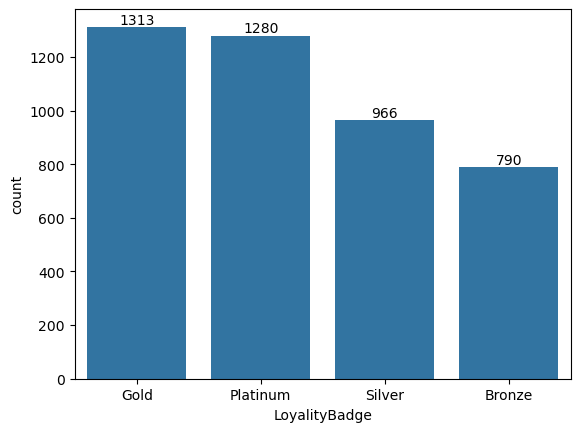

In [194]:
# Distribution of the customers

ax = sns.countplot(x=segmented_data['LoyalityBadge'],
             order =segmented_data['LoyalityBadge'].value_counts().index )
ax.bar_label(ax.containers[0])
plt.show()